<a href="https://colab.research.google.com/github/anaberereta-hue/Trabajos-Colab/blob/main/taller_datos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [102]:
df=pd.read_csv('/content/dirty_cafe_sales.csv')

In [103]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [104]:
df.duplicated()
df.duplicated().sum()

np.int64(0)

¿Cuáles son las columnas presentes en el dataset?

In [105]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

¿Cuáles son los tipos de datos presentes en el data set?

In [106]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


¿Cuántos datos nulos existen por cada categoría?

In [107]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


¿Qué indica la columna Transaction ID? ¿Las cantidades son únicas?

In [108]:
#La columna Transaction ID indica el número de identificacion de cada transacción hecha.
df['Transaction ID'].unique()

array(['TXN_1961373', 'TXN_4977031', 'TXN_4271903', ..., 'TXN_5255387',
       'TXN_7695629', 'TXN_6170729'], dtype=object)

Analiza la columna Item cuantos valores únicos tiene?

In [109]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [110]:
len(df['Item'].unique())

11

In [111]:
#define un arreglo que contiene los valores únicos de la columna 'Item'
columns=df['Item'].unique()

In [112]:
#Para cada item imprime los valores únicos
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee ['2.0' nan 'ERROR' 'UNKNOWN']
Cake ['3.0' nan 'UNKNOWN' 'ERROR']
Cookie ['1.0' 'UNKNOWN' nan 'ERROR']
Salad ['5.0' 'ERROR' 'UNKNOWN' nan]
Smoothie ['4.0' nan 'UNKNOWN' 'ERROR']
UNKNOWN ['3.0' '1.0' '5.0' '4.0' '1.5' '2.0' nan 'UNKNOWN' 'ERROR']
Sandwich ['4.0' nan 'ERROR' 'UNKNOWN']
nan []
ERROR ['1.5' '3.0' '5.0' nan '4.0' '2.0' '1.0' 'UNKNOWN' 'ERROR']
Juice ['3.0' nan 'UNKNOWN' 'ERROR']
Tea ['1.5' nan 'ERROR' 'UNKNOWN']


Para cada uno de los items coloca el precio correcto

In [113]:
df['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [114]:
#Se uso la IA para para que corrigiera el codigo que se coloco para que pudiera funcionar, y coloco &, este código se puede reutilizar
#para eliminar en items, y precios por unidad
df.loc[(df['Item'] == 'Coffee') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 2.0
df.loc[(df['Item'] == 'Coffee') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 2.0



In [115]:
df.loc[(df['Item'] == 'Cake') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 3.0
df.loc[(df['Item'] == 'Cake') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 3.0

In [116]:
df.loc[(df['Item'] == 'Cookie') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 1.0
df.loc[(df['Item'] == 'Cookie') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 1.0

In [117]:
df.loc[(df['Item'] == 'Salad') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 5.0
df.loc[(df['Item'] == 'Salad') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 5.0

In [118]:
df.loc[(df['Item'] == 'Smoothie') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 4.0
df.loc[(df['Item'] == 'Smoothie') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 4.0

In [119]:
df.loc[(df['Item'] == 'Sandwich') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 4.0
df.loc[(df['Item'] == 'Sandwich') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 4.0

In [120]:
df.loc[(df['Item'] == 'Juice') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 3.0
df.loc[(df['Item'] == 'Juice') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 3.0

In [121]:
df.loc[(df['Item'] == 'Tea') & (df['Price Per Unit'] == 'ERROR'), 'Price Per Unit'] = 1.5
df.loc[(df['Item'] == 'Tea') & (df['Price Per Unit'] == 'UNKNOWN'), 'Price Per Unit'] = 1.5

In [122]:
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee ['2.0' nan 2.0]
Cake ['3.0' nan 3.0]
Cookie ['1.0' 1.0 nan]
Salad ['5.0' 5.0 nan]
Smoothie ['4.0' nan 4.0]
UNKNOWN ['3.0' '1.0' '5.0' '4.0' '1.5' '2.0' nan 'UNKNOWN' 'ERROR']
Sandwich ['4.0' nan 4.0]
nan []
ERROR ['1.5' '3.0' '5.0' nan '4.0' '2.0' '1.0' 'UNKNOWN' 'ERROR']
Juice ['3.0' nan 3.0]
Tea ['1.5' nan 1.5]


En este caso UNKNOWN ['3.0' '1.0' '5.0' '4.0' '1.5' '2.0' nan 'UNKNOWN' 'ERROR'] en base al precio coloca en el item UNKNOWKN el item correspondiente

In [123]:
df.loc[(df['Item'] == 'UNKNOWN') & (df['Price Per Unit'] == '1.0'), 'Item'] = 'Cookie'
df.loc[(df['Item'] == 'UNKNOWN') & (df['Price Per Unit'] == '5.0'), 'Item'] = 'Salad'
df.loc[(df['Item'] == 'UNKNOWN') & (df['Price Per Unit'] == '1.5'), 'Item'] = 'Tea'
df.loc[(df['Item'] == 'UNKNOWN') & (df['Price Per Unit'] == '2.0'), 'Item'] = 'Coffee'

In [124]:
#Saber cuantos datos esta identificacod como UNKNOWN en Item
len(df[df['Item'] == 'UNKNOWN'])


165

In [125]:
#Eliminamos 165 datos debido a que se desconce la diferencia de UNKNOWN con dos precios diferentes, para evitar el sesgo de error
df = df[df['Item'] != 'UNKNOWN']

In [126]:
#Confirmar que ya no haya datos con UNKNOWN
len(df[df['Item'] == 'UNKNOWN'])

0

In [127]:
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee ['2.0' nan 2.0]
Cake ['3.0' nan 3.0]
Cookie ['1.0' 1.0 nan]
Salad ['5.0' 5.0 nan]
Smoothie ['4.0' nan 4.0]
UNKNOWN []
Sandwich ['4.0' nan 4.0]
nan []
ERROR ['1.5' '3.0' '5.0' nan '4.0' '2.0' '1.0' 'UNKNOWN' 'ERROR']
Juice ['3.0' nan 3.0]
Tea ['1.5' nan 1.5]


En el caso ERROR ['1.5' '3.0' '5.0' nan '4.0' '2.0' '1.0' 'UNKNOWN' 'ERROR'] en base al precio coloca el item correspondiente en lugar de error

In [128]:
df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '1.5'), 'Item'] = 'Tea'
df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '5.0'), 'Item'] = 'Salad'
df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '2.0'), 'Item'] = 'Coffee'
df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '1.0'), 'Item'] = 'Cookie'

/tmp/ipykernel_16263/1409745170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '1.5'), 'Item'] = 'Tea'
/tmp/ipykernel_16263/1409745170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Item'] == 'ERROR') & (df['Price Per Unit'] == '5.0'), 'Item'] = 'Salad'
/tmp/ipykernel_16263/1409745170.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df['Item'] ==

In [129]:
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee ['2.0' nan 2.0]
Cake ['3.0' nan 3.0]
Cookie ['1.0' 1.0 nan]
Salad ['5.0' 5.0 nan]
Smoothie ['4.0' nan 4.0]
UNKNOWN []
Sandwich ['4.0' nan 4.0]
nan []
ERROR ['3.0' nan '4.0' 'UNKNOWN' 'ERROR']
Juice ['3.0' nan 3.0]
Tea ['1.5' nan 1.5]


In [130]:
len(df[df['Item'] == 'ERROR'])

151

In [131]:
df = df[df['Item'] != 'ERROR']
len(df[df['Item'] == 'ERROR'])

0

In [132]:
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Price Per Unit']=df['Price Per Unit'].astype(float)

In [133]:
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee [ 2. nan]
Cake [ 3. nan]
Cookie [ 1. nan]
Salad [ 5. nan]
Smoothie [ 4. nan]
UNKNOWN []
Sandwich [ 4. nan]
nan []
ERROR []
Juice [ 3. nan]
Tea [1.5 nan]


In [134]:
#Se uso IA para poder cambiar NaN a sus precios correspondientes segun su item
df.loc[(df['Item'] == 'Cookie') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 1.0
df.loc[(df['Item'] == 'Salad') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 5.0
df.loc[(df['Item'] == 'Tea') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 1.5
df.loc[(df['Item'] == 'Coffee') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 2.0
df.loc[(df['Item'] == 'Cake') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 3.0
df.loc[(df['Item'] == 'Smoothie') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 4.0
df.loc[(df['Item'] == 'Sandwich') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 4.0
df.loc[(df['Item'] == 'Juice') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 3.0


In [135]:
for item in columns:
    prices = df[df['Item'] == item]['Price Per Unit'].unique()
    print(item, prices)

Coffee [2.]
Cake [3.]
Cookie [1.]
Salad [5.]
Smoothie [4.]
UNKNOWN []
Sandwich [4.]
nan []
ERROR []
Juice [3.]
Tea [1.5]


En las columnas 'total spent y quantity reemplaza los valores desconocidos por np.nan y convierte en tipo float esa columna, realiza lo mismo con la columna quantity

In [136]:
df['Total Spent'] = df['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Total Spent']=df['Total Spent'].astype(float)

In [137]:
df['Quantity'] = df['Quantity'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Quantity']=df['Quantity'].astype(float)

Para UNKNOWN [ nan 'UNKNOWN' 'ERROR'] y ERROR [ nan 'UNKNOWN' 'ERROR'] calcula la razón entre df['Total Spent']/df['Quantity'] el valor obtenido puede indicar a que item corresponde?

In [138]:
df


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [139]:
#Calcular 'precio_unitario_calculado'
df['precio_unitario_calculado'] = df['Total Spent'] / df['Quantity']

In [140]:
#Rellenar 'Item' para precios, donde 'Item' es NaN
df.loc[(df['Item'].isna()) & (df['precio_unitario_calculado'] == 1.0), 'Item'] = 'Cookie'
df.loc[(df['Item'].isna()) & (df['precio_unitario_calculado'] == 1.5), 'Item'] = 'Tea'
df.loc[(df['Item'].isna()) & (df['precio_unitario_calculado'] == 2.0), 'Item'] = 'Coffee'
df.loc[(df['Item'].isna()) & (df['precio_unitario_calculado'] == 5.0), 'Item'] = 'Salad'


In [141]:
# Rellenar Price Per Unit en donde dice NaN
# Esto cubre tanto los ítems recién inferidos como aquellos que ya estaban pero tenían el precio NaN
df.loc[(df['Item'] == 'Cookie') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 1.0
df.loc[(df['Item'] == 'Tea') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 1.5
df.loc[(df['Item'] == 'Coffee') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 2.0
df.loc[(df['Item'] == 'Salad') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 5.0

In [142]:
# Manejar artículos ambiguos si su 'Item' se conocía pero 'Price Per Unit' era NaN
df.loc[(df['Item'] == 'Cake') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 3.0
df.loc[(df['Item'] == 'Juice') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 3.0
df.loc[(df['Item'] == 'Smoothie') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 4.0
df.loc[(df['Item'] == 'Sandwich') & (df['Price Per Unit'].isna()), 'Price Per Unit'] = 4.0

In [143]:
# Eliminar la columna temporal 'precio_unitario_calculado'
df = df.drop(columns=['precio_unitario_calculado'])
display(df[['Item', 'Price Per Unit', 'Total Spent', 'Quantity']].isnull().sum())

,0
Item,192
Price Per Unit,14
Total Spent,482
Quantity,460


Realiza una gráfica de histograma de los precios por item

(array([   0.,  500., 1000., 1500., 2000., 2500., 3000.]),
 [Text(0, 0.0, '0'),
  Text(0, 500.0, '500'),
  Text(0, 1000.0, '1000'),
  Text(0, 1500.0, '1500'),
  Text(0, 2000.0, '2000'),
  Text(0, 2500.0, '2500'),
  Text(0, 3000.0, '3000')])

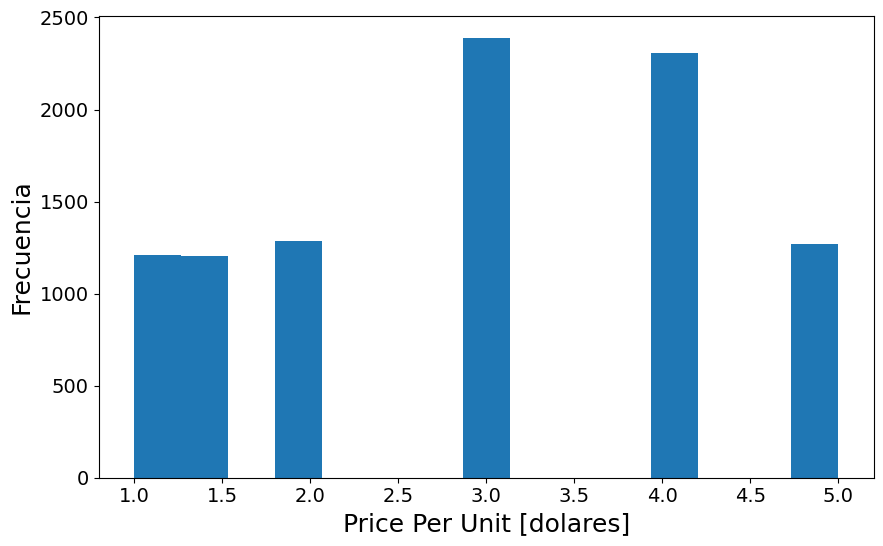

In [144]:
# Crear una figura con un tamaño específico para el gráfico
plt.figure(figsize=(10,6))
# Crear un histograma de la columna 'Price Per Unit' con 15 divisiones (bins)
plt.hist(df['Price Per Unit'],bins=15)
# Establecer la etiqueta del eje X
plt.xlabel("Price Per Unit [dolares]", fontsize=18)
# Establecer la etiqueta del eje Y
plt.ylabel("Frecuencia", fontsize=18)
# Establecer el tamaño de la fuente para las marcas del eje X
plt.xticks(fontsize=14)
# Establecer el tamaño de la fuente para las marcas del eje Y
plt.yticks(fontsize=14)

In [145]:
df[['Item','Price Per Unit']]

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
4,Coffee,2.0
...,...,...
9995,Coffee,2.0
9996,Cookie,1.0
9997,Coffee,2.0
9998,Cookie,1.0


In [146]:
df[df['Item']=='UNKNOWN']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [147]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [148]:
df.to_csv('/var/Taller_datos_1',index=False)